In [1]:
import zipfile
import os

# Extract the zip file
with zipfile.ZipFile('archive (4).zip', 'r') as zip_ref:
    zip_ref.extractall('.')

print("✅ Done! Files:")
for f in os.listdir('.'):
    print(f)

✅ Done! Files:
.config
googleplaystore_user_reviews.csv
license.txt
googleplaystore.csv
archive (4).zip
sample_data


In [2]:
import pandas as pd
import numpy as np

# Load dataset
df = pd.read_csv('googleplaystore.csv')

# Drop duplicates and nulls
df.drop_duplicates(inplace=True)
df.dropna(inplace=True)

# Clean Installs → numeric
df['Installs'] = df['Installs'].str.replace('[+,]', '', regex=True)
df['Installs'] = pd.to_numeric(df['Installs'], errors='coerce')

# Clean Price → numeric
df['Price'] = df['Price'].str.replace('$', '', regex=False)
df['Price'] = pd.to_numeric(df['Price'], errors='coerce')

# Clean Size → MB
def convert_size(size):
    if 'M' in str(size):
        return float(str(size).replace('M', ''))
    elif 'k' in str(size):
        return float(str(size).replace('k', '')) / 1024
    else:
        return None

df['Size_MB'] = df['Size'].apply(convert_size)

# Clean Android Version → numeric
df['Android Ver'] = df['Android Ver'].str.extract(r'(\d+\.\d+|\d+)')
df['Android Ver'] = pd.to_numeric(df['Android Ver'], errors='coerce')

# Calculate Revenue
df['Revenue'] = df['Price'] * df['Installs']

# Drop nulls after cleaning
df.dropna(subset=['Installs', 'Price', 'Size_MB', 'Android Ver', 'Revenue'], inplace=True)

print("✅ Cleaning done! Shape:", df.shape)
df.head()

✅ Cleaning done! Shape: (7365, 15)


,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver,Size_MB,Revenue
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19M,10000,Free,0.0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0,19.0,0.0
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,500000,Free,0.0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0,14.0,0.0
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7M,5000000,Free,0.0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0,8.7,0.0
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25M,50000000,Free,0.0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2,25.0,0.0
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8M,100000,Free,0.0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4,2.8,0.0


In [3]:
# Apply all filters
filtered_df = df[
    (df['Installs'] >= 10000) &
    (df['Revenue'] >= 10000) &
    (df['Android Ver'] > 4.0) &
    (df['Size_MB'] > 15) &
    (df['Content Rating'] == 'Everyone') &
    (df['App'].str.len() <= 30)
]

print("✅ After filters, shape:", filtered_df.shape)

# Get top 3 categories by installs
top3_categories = (
    filtered_df.groupby('Category')['Installs']
    .sum()
    .nlargest(3)
    .index.tolist()
)

print("Top 3 Categories:", top3_categories)

# Filter for top 3 categories only
filtered_df = filtered_df[filtered_df['Category'].isin(top3_categories)]

# Group by Category and Type (Free/Paid)
grouped = filtered_df.groupby(['Category', 'Type']).agg(
    Avg_Installs=('Installs', 'mean'),
    Avg_Revenue=('Revenue', 'mean')
).reset_index()

print("✅ Grouped data:")
print(grouped)

✅ After filters, shape: (31, 15)
Top 3 Categories: ['FAMILY', 'PERSONALIZATION', 'PHOTOGRAPHY']
✅ Grouped data:
          Category  Type    Avg_Installs   Avg_Revenue
0           FAMILY  Paid   381428.571429  7.969000e+05
1  PERSONALIZATION  Paid   670000.000000  6.666333e+05
2      PHOTOGRAPHY  Paid  1000000.000000  5.990000e+06


Current IST hour: 13


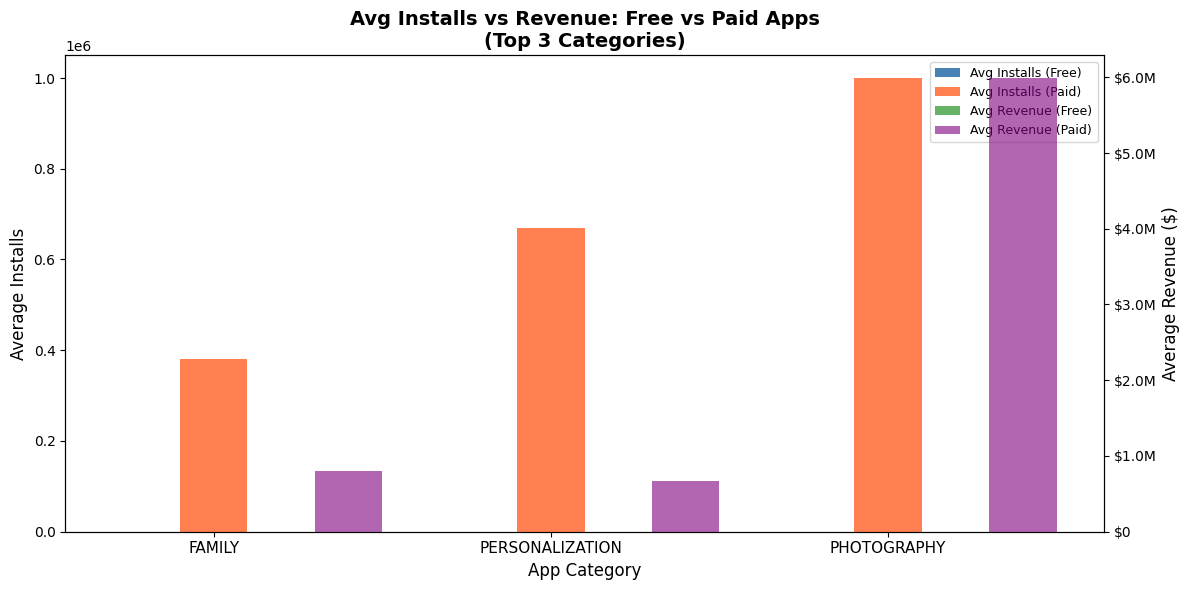

✅ Chart saved as task3_dualaxis_chart.png


In [6]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from datetime import datetime
import pytz
import numpy as np

# Check current IST time
ist = pytz.timezone('Asia/Kolkata')
current_hour = datetime.now(ist).hour

print(f"Current IST hour: {current_hour}")

if not (13 <= current_hour < 14):
    print("⛔ Chart is only available between 1 PM and 2 PM IST. Please come back then.")

else:
    fig, ax1 = plt.subplots(figsize=(12, 6))

    categories = top3_categories
    x = np.arange(len(categories))
    width = 0.2

    app_types = ['Free', 'Paid']
    colors_installs = ['steelblue', 'coral']
    colors_revenue = ['green', 'purple']

    for i, app_type in enumerate(app_types):
        subset = grouped[grouped['Type'] == app_type].set_index('Category')
        installs_vals = [subset.loc[cat, 'Avg_Installs'] if cat in subset.index else 0 for cat in categories]
        ax1.bar(x + i*width - width, installs_vals, width,
                label=f'Avg Installs ({app_type})',
                color=colors_installs[i])

    ax1.set_ylabel('Average Installs', fontsize=12)
    ax1.set_xticks(x)
    ax1.set_xticklabels(categories, fontsize=11)
    ax1.set_xlabel('App Category', fontsize=12)

    ax2 = ax1.twinx()
    for i, app_type in enumerate(app_types):
        subset = grouped[grouped['Type'] == app_type].set_index('Category')
        revenue_vals = [subset.loc[cat, 'Avg_Revenue'] if cat in subset.index else 0 for cat in categories]
        ax2.bar(x + i*width + width, revenue_vals, width,
                label=f'Avg Revenue ({app_type})',
                color=colors_revenue[i], alpha=0.6)

    ax2.set_ylabel('Average Revenue ($)', fontsize=12)
    ax2.yaxis.set_major_formatter(mticker.FuncFormatter(
        lambda val, _: f'${val/1e6:.1f}M' if val >= 1e6 else f'${int(val):,}'
    ))

    plt.title('Avg Installs vs Revenue: Free vs Paid Apps\n(Top 3 Categories)',
              fontsize=14, fontweight='bold')

    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right', fontsize=9)

    plt.tight_layout()
    plt.savefig('task3_dualaxis_chart.png', dpi=150)
    plt.show()
    print("✅ Chart saved as task3_dualaxis_chart.png")

In [7]:
import os
print(os.listdir('.'))

['.config', 'googleplaystore_user_reviews.csv', 'license.txt', 'task3_dualaxis_chart.png', 'googleplaystore.csv', 'archive (4).zip', 'sample_data']
